<a href="https://colab.research.google.com/github/samuel127jules/es22452/blob/main/Lab9ES2245.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install obspy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats, signal
import obspy
from obspy.clients.fdsn import Client

plt.rcParams['figure.figsize'] = [10, 6]
%matplotlib inline

In [2]:
# Data: Rows are rock samples, Columns are pressure levels
perm_data = np.array([
    [15.2, 14.8, 13.9], # Sample 1
    [10.1, 9.5, 8.2],   # Sample 2
    [25.4, 24.1, 23.0], # Sample 3
    [5.5, 5.0, 4.1],    # Sample 4
    [18.9, 17.5, 16.2]  # Sample 5
])


result = stats.friedmanchisquare(perm_data[:, 0], perm_data[:, 1], perm_data[:, 2])
print(result)

FriedmanchisquareResult(statistic=np.float64(10.0), pvalue=np.float64(0.006737946999085468))


In [3]:
depth = np.array([100, 200, 300, 400, 500, 600, 700, 800])
gold_ppm = np.array([0.2, 0.5, 1.1, 2.4, 5.1, 10.2, 11.5, 12.1])

rho, p_val = stats.spearmanr(depth, gold_ppm)

print(f"Spearman correlation: {rho:.4f}")
print(f"P-value: {p_val:.4f}")


Spearman correlation: 1.0000
P-value: 0.0000


The Nyquist frequency is 6.0 Hz. Since our signal is 10 Hz, we expect aliasing.


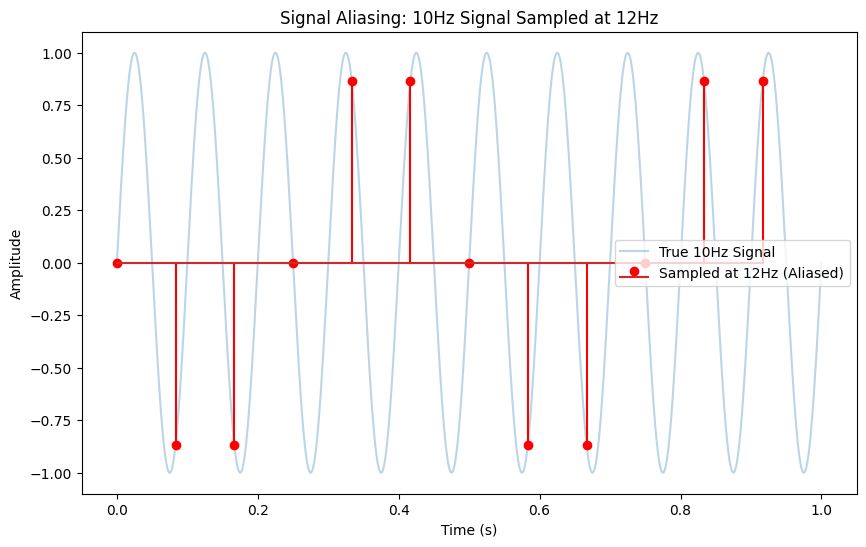

In [4]:
t_fine = np.linspace(0, 1, 1000)
f_signal = 10
y_true = np.sin(2 * np.pi * f_signal * t_fine)

fs_low = 12
t_low = np.arange(0, 1, 1/fs_low)
y_low = np.sin(2 * np.pi * f_signal * t_low)

plt.plot(t_fine, y_true, label='True 10Hz Signal', alpha=0.3)
plt.stem(t_low, y_low, 'r', label='Sampled at 12Hz (Aliased)')

nyquist = fs_low / 2
print(f"The Nyquist frequency is {nyquist} Hz. Since our signal is {f_signal} Hz, we expect aliasing.")

plt.title('Signal Aliasing: 10Hz Signal Sampled at 12Hz')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.legend()
plt.show()


Detected Time Delay: 0.392 seconds


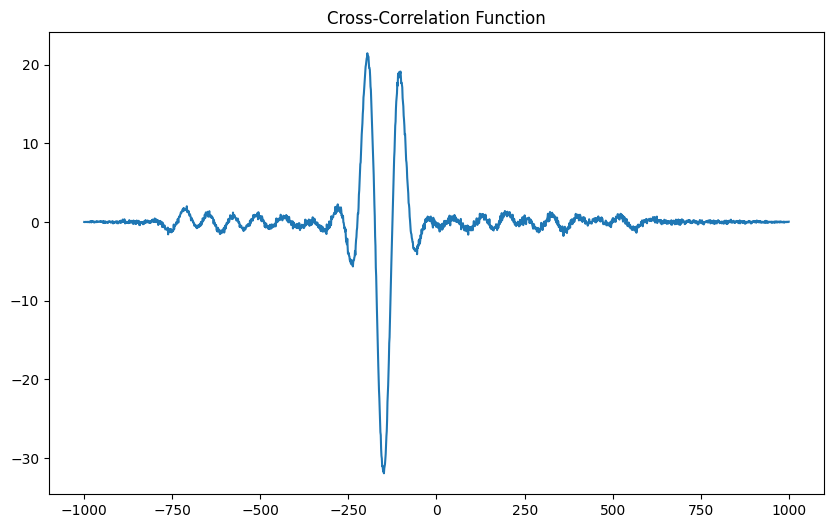

In [5]:
t = np.linspace(0, 2, 1000)
def pulse(time, center):
    return np.exp(-(time-center)**2 / 0.01) * np.sin(2 * np.pi * 5 * time)

sensor1 = pulse(t, 0.5) + np.random.normal(0, 0.1, 1000)
sensor2 = pulse(t, 0.8) + np.random.normal(0, 0.1, 1000)

correlation = np.correlate(sensor1, sensor2, mode='full')
lags = np.arange(-len(sensor1) + 1, len(sensor1))
best_lag_idx = np.argmax(correlation)
time_delay = lags[best_lag_idx] * (t[1] - t[0])

print(f"Detected Time Delay: {abs(time_delay):.3f} seconds")

plt.plot(lags, correlation)
plt.title("Cross-Correlation Function")
plt.show()

/usr/local/lib/python3.12/dist-packages/obspy/clients/fdsn/client.py:251: ObsPyDeprecationWarning: IRIS is now EarthScope, please consider changing the FDSN client short URL to 'EARTHSCOPE'.
  warnings.warn(msg, ObsPyDeprecationWarning)


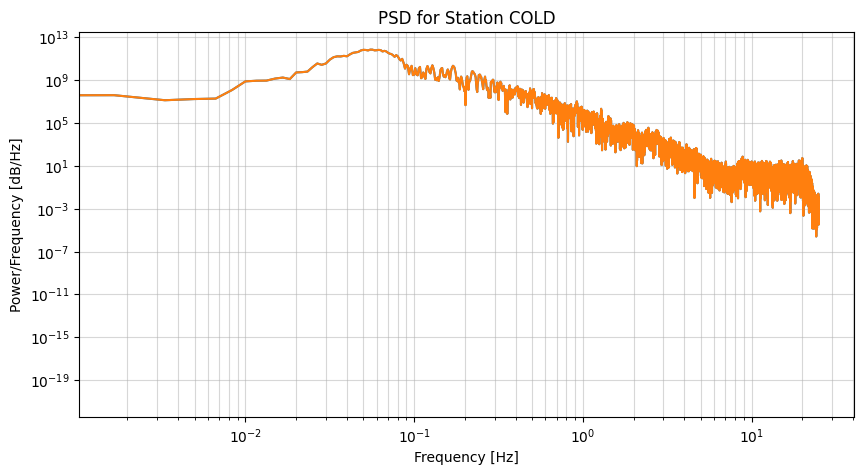

In [6]:
client = Client("IRIS")
starttime = obspy.UTCDateTime("2023-07-16T06:48:00") # M7.2 Alaska Event
st = client.get_waveforms("AK", "COLD", "", "BHZ", starttime, starttime + 600)
tr = st[0]

tr.detrend('linear')
tr.taper(0.05)

freqs, psd = signal.periodogram(tr.data, fs=tr.stats.sampling_rate)

plt.figure(figsize=(10, 5))
plt.loglog(freqs, psd)
plt.loglog(freqs, psd)
plt.semilogy()

plt.title(f"PSD for Station {tr.stats.station}")
plt.xlabel("Frequency [Hz]")
plt.ylabel("Power/Frequency [dB/Hz]")
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.show()

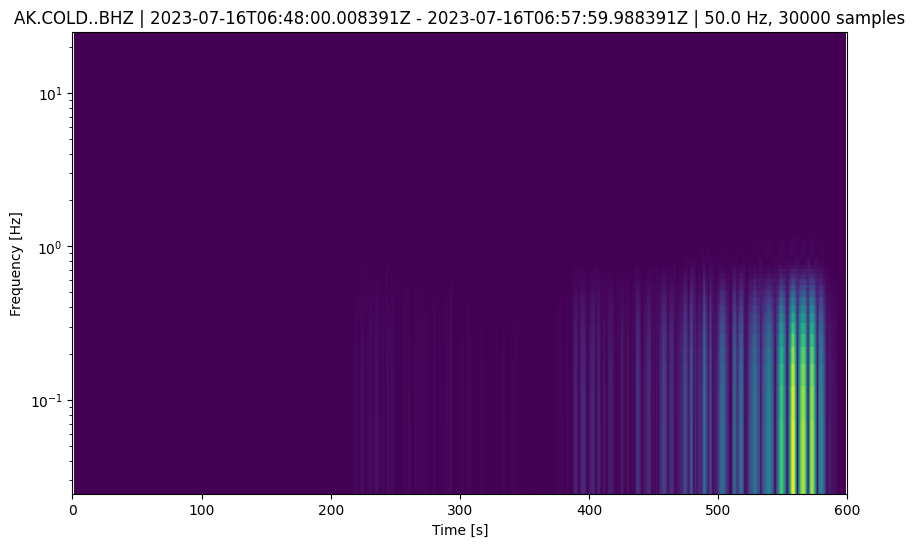

In [7]:
tr.spectrogram(log=True)

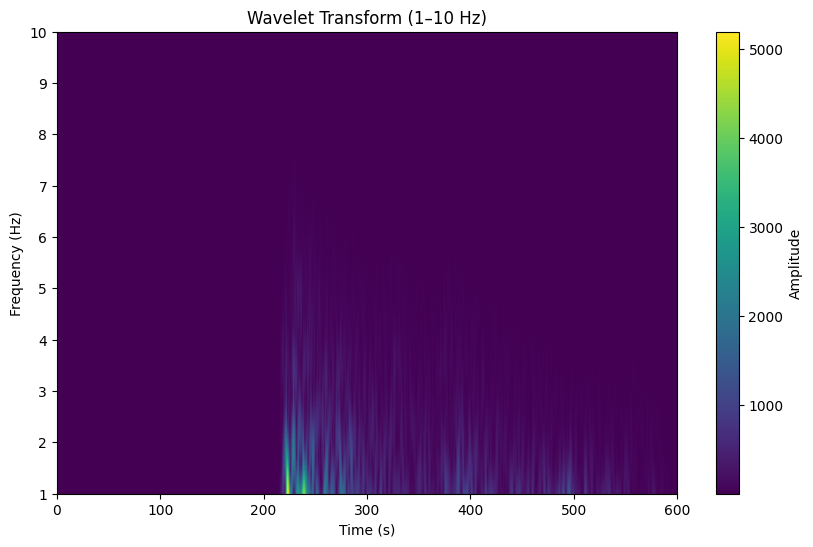

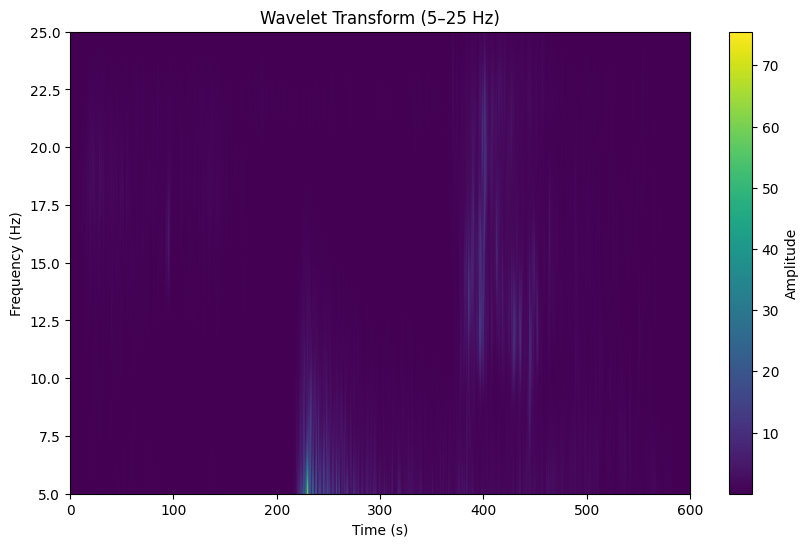

In [8]:
from obspy.signal.tf_misfit import cwt

data = tr.data
dt = tr.stats.delta
npts = tr.stats.npts

t = np.linspace(0, dt * npts, npts)

f_min = 1
f_max = 10

scalogram1 = cwt(data, dt, 8, f_min, f_max)

plt.figure()
plt.imshow(np.abs(scalogram1),
           extent=[t[0], t[-1], f_min, f_max],
           aspect='auto',
           origin='lower')

plt.title("Wavelet Transform (1–10 Hz)")
plt.xlabel("Time (s)")
plt.ylabel("Frequency (Hz)")
plt.colorbar(label="Amplitude")
plt.show()

f_min = 5
f_max = 25

scalogram2 = cwt(data, dt, 8, f_min, f_max)

plt.figure()
plt.imshow(np.abs(scalogram2),
           extent=[t[0], t[-1], f_min, f_max],
           aspect='auto',
           origin='lower')

plt.title("Wavelet Transform (5–25 Hz)")
plt.xlabel("Time (s)")
plt.ylabel("Frequency (Hz)")
plt.colorbar(label="Amplitude")
plt.show()

Question 1: Frequency domain makes more sense because it splits the signal into multiple frequencies. This makes it easier to identify.

Question 2: Spectrograms show how frequencies change over time. Vertical blasts are sudden events like new seismic waves.

Question 3: Wavelets would be the better choice for a short or sudden event because they are more sensitive to "jolts" or "shocks".

Question 4: I would choose a low pass filter because of the speed of waves compared to something high frequency like eaerthquakes.